### **Control Variates for a GARCH Model**
  
**Reference paper**: Mira, Solgi & Imparato (2013), *Zero variance Markov chain Monte Carlo for Bayesian estimators*, Stat Comput 23:653–662.  

DOI: [10.1007/s11222-012-9344-6](https://doi.org/10.1007/s11222-012-9344-6)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
rng = np.random.default_rng(42)

Question 1 :

As a little reminder, the model used in the paper is the Normal-GARCH(1,1) one (Bollerslev 1986) as defined below:
$$
r_t \mid \mathcal{F}_{t-1} \sim \mathcal{N}(0,\, h_t),
\qquad
h_t = \omega_1 + \omega_2\, r_{t-1}^2 + \omega_3\, h_{t-1},
$$
with parameters $\theta = (\omega_1, \omega_2, \omega_3)$ satisfying $\omega_1 > 0$, $\omega_2 \ge 0$, $\omega_3 \ge 0$, and $\omega_2 + \omega_3 < 1$ (covariance stationarity).

Following the paper (Section 6.3) we place independent truncated-normal priors on each parameter:
$$
\omega_j \sim \mathcal{N}(0, \sigma_0^2)\, \mathbf{1}_{\omega_j \ge 0}, \quad j=1,2,3.
$$
with $\sigma_0 = 1$.

On top of that, the log-likelihood is defined as:
$$
\ell(\theta) = -\frac{1}{2}\sum_{t=1}^{T}\left[\log h_t + \frac{r_t^2}{h_t}\right].
$$
and the log-prior (up to a constant, ignoring the half-normal normalisation which cancels in the MH ratio) as:
$$
\log \pi(\theta) = -\frac{1}{2\sigma_0^2}\sum_j \omega_j^2 + \text{const}, \quad \text{with } \omega_j \ge 0.
$$

In [2]:
# GARCH(1,1) helpers 

# omega1 or baseline level. It's basicallh the long-run floor of variance or to put
# it simply it says that even if nothing happened yesterday, the market still has
# some background volatility. 

# omega2 or ARCH term : it depicts the reaction or more specifically, how much does
# today's variance react to yesterday's news? Can be seen as the "surprise" component.

# omega3 or GARCH term (persistence): basically how much does today's variance inherit
# from yesterday's variance? It captures the "memory" aspect.

def compute_variances(returns, omega1, omega2, omega3):
    # Recursively compute the conditional variance sequence h_t
    T = len(returns)
    h = np.empty(T)
    # need to compute h0 since we have no previous return/variance which iw why
    # we go for the unconditional and long-run variance. This leads us to
    # h_t = h_{t-1} = h^ i.e. h^ = \omega_1 + (\omega_2 + \omega_3) h^
    h[0] = omega1 / (1.0 - omega2 - omega3)   # unconditional variance
    for t in range(1, T):
        h[t] = omega1 + omega2 * returns[t-1]**2 + omega3 * h[t-1]
    return h


def log_likelihood(returns, omega1, omega2, omega3):
    # Gaussian GARCH(1,1) log-likelihood 
    # the conditions below enforces the stationarity constraints
    if omega1 <= 0 or omega2 < 0 or omega3 < 0 or omega2 + omega3 >= 1:
        return -np.inf
    h = compute_variances(returns, omega1, omega2, omega3)
    if np.any(h <= 0):
        return -np.inf
    return -0.5 * np.sum(np.log(h) + returns**2 / h)


def log_prior(omega1, omega2, omega3, sigma0=1.0):
    # Log of truncated-normal prior (positivity constraints)
    if omega1 <= 0 or omega2 < 0 or omega3 < 0:
        return -np.inf
    return -0.5 / sigma0**2 * (omega1**2 + omega2**2 + omega3**2)


def log_posterior(returns, omega1, omega2, omega3, sigma0=1.0):
    # applying Bayes' rule
    lp = log_prior(omega1, omega2, omega3, sigma0)
    if lp == -np.inf:
        return -np.inf
    return lp + log_likelihood(returns, omega1, omega2, omega3)

# Key element to notice from why why everything returns log-probabilities
# rather than probabilities. We know that the MH acceptance ratio is 
# r = pi(theta')/pi(theta), which using the log becomes: lp_proposal - lp_current.
# It avoids numerical underflow as raw probability of 3000 time series
# would be really small numbers

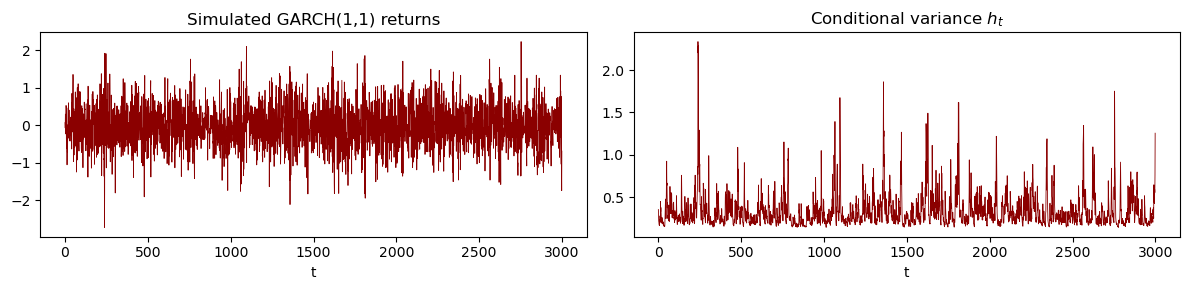

True parameters: ω₁=0.055, ω₂=0.245, ω₃=0.6


In [52]:
# Simulate GARCH(1,1) data 

def simulate_garch(T, omega1, omega2, omega3, seed=0):
    rng_sim = np.random.default_rng(seed)
    h = np.empty(T)
    r = np.empty(T)
    h[0] = omega1 / (1.0 - omega2 - omega3) # same as defined before
    # draw r0 from h0
    r[0] = rng_sim.normal(0, np.sqrt(h[0]))
    for t in range(1, T):
        h[t] = omega1 + omega2 * r[t-1]**2 + omega3 * h[t-1]
        r[t] = rng_sim.normal(0, np.sqrt(h[t]))
    return r, h

# true parameters (same order of magnitude as the paper's DM/GBP estimates)
TRUE_OMEGA = (0.055, 0.245, 0.600)   # (omega1, omega2, omega3)
T_SIM = 3000

r_sim, h_sim = simulate_garch(T_SIM, *TRUE_OMEGA)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(r_sim, lw=0.6, color='darkred')
axes[0].set_title('Simulated GARCH(1,1) returns')
axes[0].set_xlabel('t')
axes[1].plot(h_sim, lw=0.6, color='darkred')
axes[1].set_title('Conditional variance $h_t$')
axes[1].set_xlabel('t')
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/simulatedgarch.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'True parameters: ω₁={TRUE_OMEGA[0]}, ω₂={TRUE_OMEGA[1]}, ω₃={TRUE_OMEGA[2]}')

For the simulated returns, we notice that the returns oscillate around zero, which is expected since the GARCH model has zero mean by construction. Most returns stay within roughly ±1.5%, with occasional spikes exceeding ±2.5%. This is consistent with the unconditional standard deviation of $\sqrt{0.055 / (1 - 0.245 - 0.600)} \approx 0.6%$ per day. Moreover we can notice some volatility clustering (btw distinct calm and turbulent stretches) as expected for a GARCH model.

Regarding the conditional variance, we can observe that it never reaches zero. Its floor around 0.2-0.3 comes from $\omega_1 = 0.055$. There are several sharp spikes (the biggest one being around $t \approx 300-350$ reaching above 2.0, meaning the daily standard deviation briefly reached $\sqrt{2} \approx 1.4%$).

On top of that, let's remind that every spike in the variance chart corresponds to a cluster of large returns in the return chart. Indeed, they are not independent plots since the variance at each point is literally computed from both the previous return and the previous variance.

Thus we want draws from $\pi(\theta \mid r) \propto \pi(\theta) \times L(\theta \mid r)$, but we notice that this posterior has no closed form (e.g. it's not a Gaussian, Gamma, or any standard distribution that can be inverted). Indeed, to evaluate $L(\theta \mid r)$ we have to run the recursive loop:

$$h_t = \omega_1 + \omega_2 r_{t-1}^2 + \omega_3 h_{t-1}$$

That recursion makes the likelihood a complicated nonlinear function of $\theta$. That's why we have decided to use the **Random Walk Metropolis (RWM)** sampler since it only needs to evaluate the posterior at two points per iteration (current and proposed), and not to know its shape in advance. The ratio:

$$\frac{\pi(\theta' \mid r)}{\pi(\theta \mid r)}$$

is all we need, and the normalising constant cancels. RWM turns evaluations into samples. The proposal is a Gaussian random walk in the unconstrained space:
$$\theta' = \theta + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\, \tau^2 I_3).$$
where $\tau$ is the step size of the random walk. Positivity constraints are enforced through the log-posterior (which returns $-\infty$ outside the support).

In [4]:
#  Random Walk Metropolis 

def rwm_garch(returns, N, tau, theta_init=None, seed=1, sigma0=1.0):
    """
    Random Walk Metropolis for the GARCH(1,1) posterior.

    Parameters
    ----------
    returns    : observed return series
    N          : number of MCMC iterations (including burn-in)
    tau        : isotropic step-size (scalar)
    theta_init : starting point (omega1, omega2, omega3); defaults to (0.05, 0.1, 0.8)
    seed       : RNG seed
    sigma0     : prior std

    Returns
    -------
    chain      : (N, 3) array of sampled parameters
    accept_rate: overall acceptance rate
    """
    rng_mcmc = np.random.default_rng(seed)
    if theta_init is None:
        theta_init = np.array([0.05, 0.10, 0.80]) # reasonable guess inside valide region

    chain = np.empty((N, 3))
    theta = np.array(theta_init, dtype=float)
    lp_current = log_posterior(returns, *theta, sigma0=sigma0)
    accepted = 0

    for i in range(N):
        # Gaussian random-walk proposal
        proposal = theta + tau * rng_mcmc.standard_normal(3) # propose a jump
        lp_proposal = log_posterior(returns, *proposal, sigma0=sigma0) # evaluate it

        # MH acceptance step (log scale)
        # if proposal has higher posterior than current, then it's always accepted
        # else, accepted with probability exp(log_alpha)
        log_alpha = lp_proposal - lp_current
        if np.log(rng_mcmc.uniform()) < log_alpha:
            theta = proposal
            lp_current = lp_proposal
            accepted += 1

        chain[i] = theta

    return chain, accepted / N


# calibrate tau 
N_PILOT = 5_000
for tau_try in [0.005, 0.01, 0.02, 0.05]:
    _, ar = rwm_garch(r_sim, N_PILOT, tau=tau_try, seed=10)
    print(f'  tau={tau_try:.3f}  →  acceptance rate {ar:.3f}')

  tau=0.005  →  acceptance rate 0.467
  tau=0.010  →  acceptance rate 0.275
  tau=0.020  →  acceptance rate 0.120
  tau=0.050  →  acceptance rate 0.025


Choosing $\tau$ = 0.01 seems to be the most relevant choice here with an acceptance rate that is almost optimal (in the literature we find around 25% to minimize efficiency loss). As a little reminder, having a too high acceptance rate means that every proposal is accepted which indicates a chain moving slowly. On the other hand, a too low one corresponds to jumps that are huge but almost never accepted so that the chain remains frozen.

In [5]:
# Main MCMC run on simulated data

TAU    = 0.01         # chosen so that acceptance rate closest to ≈ 25%
N_BURN = 2000
N_MCMC = 12000         # total = burn-in + post-burn

chain_sim, ar_sim = rwm_garch(r_sim, N_MCMC, tau=TAU, seed=42)
samples_sim = chain_sim[N_BURN:]   # discard burn-in

print(f'Acceptance rate (simulated data): {ar_sim:.3f}')
print(f'Posterior means: ω₁={samples_sim[:,0].mean():.4f}, '
      f'ω₂={samples_sim[:,1].mean():.4f}, '
      f'ω₃={samples_sim[:,2].mean():.4f}')
print(f'True values:     ω₁={TRUE_OMEGA[0]}, ω₂={TRUE_OMEGA[1]}, ω₃={TRUE_OMEGA[2]}')

Acceptance rate (simulated data): 0.271
Posterior means: ω₁=0.0585, ω₂=0.2285, ω₃=0.5972
True values:     ω₁=0.055, ω₂=0.245, ω₃=0.6


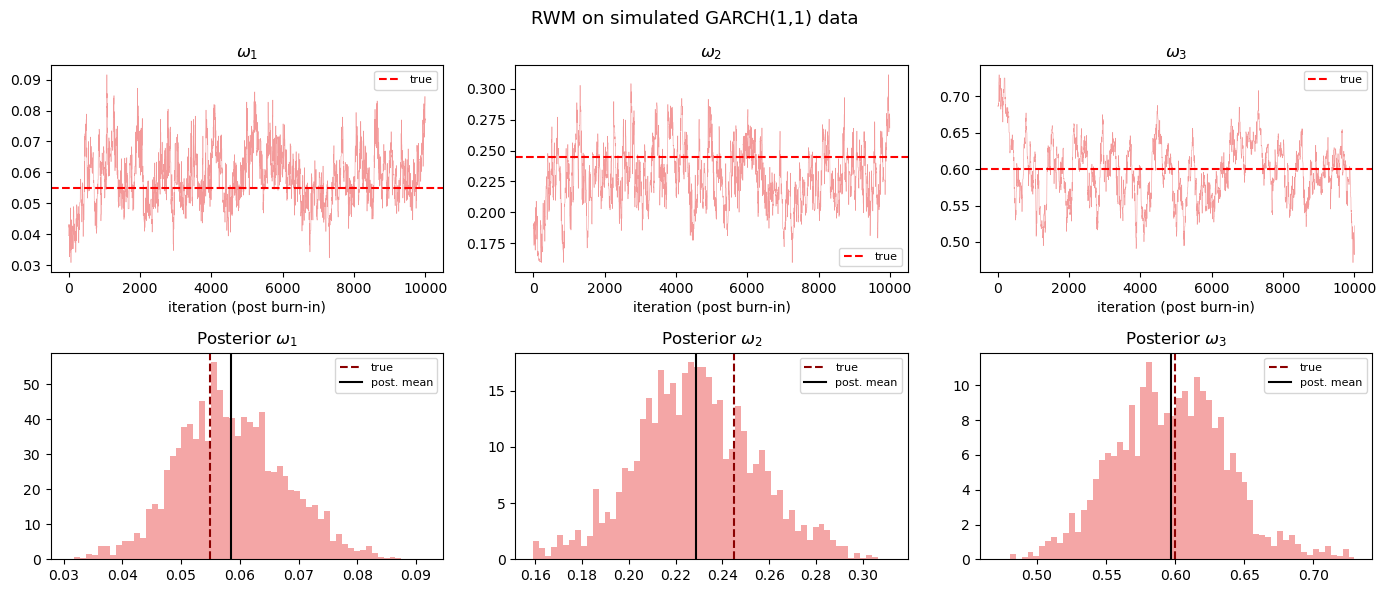

In [53]:
#  Trace plots + posterior histograms 

labels = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
true_vals = list(TRUE_OMEGA)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for k in range(3):
    # Trace
    axes[0, k].plot(samples_sim[:, k], lw=0.4, color='lightcoral', alpha=0.8)
    axes[0, k].axhline(true_vals[k], color='r', ls='--', label='true')
    axes[0, k].set_title(f'{labels[k]}')
    axes[0, k].set_xlabel('iteration (post burn-in)')
    axes[0, k].legend(fontsize=8)

    # Histogram
    axes[1, k].hist(samples_sim[:, k], bins=60, density=True, color='lightcoral', alpha=0.7)
    axes[1, k].axvline(true_vals[k], color='darkred', ls='--', label='true')
    axes[1, k].axvline(samples_sim[:, k].mean(), color='k', ls='-', label='post. mean')
    axes[1, k].set_title(f'Posterior {labels[k]}')
    axes[1, k].legend(fontsize=8)

plt.suptitle('RWM on simulated GARCH(1,1) data', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/rwm_simulatedgarch.png', dpi=200, bbox_inches='tight')
plt.show()

All three chains mix well (oscillate rapidly around a stable level with no visible trend or drift) which indicates that the sampler has converged.

On the one hand, $\omega_3$ is the best-recovered parameter. Indeed, its posterior is tightly centred around the true value 0.600, with the posterior mean nearly coinciding with it. This is expected as $\omega_3$ governs the persistence of variance and is the dominant driver of the GARCH dynamics. By definition, it makes it the most identifiable parameter.

On the other hand, $\omega_1$ and $\omega_2$ show a more spread-out posterior with a slight bias. This observation is part of an **identification problem** intrinsic to GARCH models. Indeed, these two parameters partially compensate each other: a higher baseline variance ($\omega_1 \uparrow$) can substitute for a weaker reaction to shocks ($\omega_2 \downarrow$) while producing a similar overall variance level. The posterior therefore has a ridge along this trade-off direction, making it harder to pin down each parameter individually. Nevertheless, the true values still fall within the posterior distributions which confirms the sampler is correct. We just want to pinpoint here that the uncertainty is simply large.

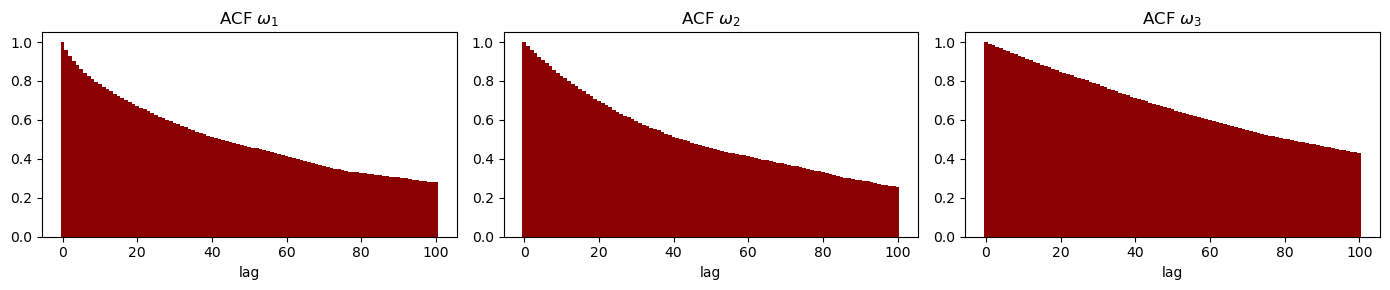

ESS $\omega_1$: 70 / 10000
ESS $\omega_2$: 76 / 10000
ESS $\omega_3$: 53 / 10000


In [54]:
# Autocorrelation function 

def acf(x, max_lag=100):
    x = x - x.mean() # centers the chains
    c0 = np.dot(x, x) # variance term at lag 0
    return np.array([np.dot(x[:len(x)-k], x[k:]) / c0 for k in range(max_lag+1)])

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for k in range(3):
    a = acf(samples_sim[:, k])
    axes[k].bar(range(len(a)), a, width=1.0, color='darkred')
    axes[k].set_title(f'ACF {labels[k]}')
    axes[k].set_xlabel('lag')
    axes[k].set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/acf.png', dpi=200, bbox_inches='tight')
plt.show()

# Effective Sample Size = N / (1 + 2 * sum of autocorrelations)
def ess(x, max_lag=200):
    a = acf(x, max_lag=max_lag)
    return len(x) / (1 + 2 * a[1:].sum())

for k in range(3):
    print(f'ESS {labels[k]}: {ess(samples_sim[:, k]):.0f} / {len(samples_sim)}')

The ACF plots show moderate but persistent autocorrelation. As we can see, all three parameters decay from 1.0 to around 0.4 by lag 100, meaning the chain still carries meaningful memory after 100 steps. The ESS quantifies 70, 76 and 53 effective samples out of 10,000 respectively, corresponding to roughly 1 independent sample per 140 iterations. 

The root cause is the isotropic RWM proposal, which does not adapt to the posterior geometry. The strong correlation between ω₁ and ω₂ creates a ridge that the sampler navigates inefficiently. 

**Real data: DEM/GBP exchange rates (Ardia 2008)**

The paper uses daily returns of the DM/GBP rate from January 1985 to December 1987 (756 observations). The full dataset from Ardia (2008) however extends to December 1991, giving 1974 observations. We still decide to choose to restrain the observations to those originally used so we can replicae the paper's exact sample.

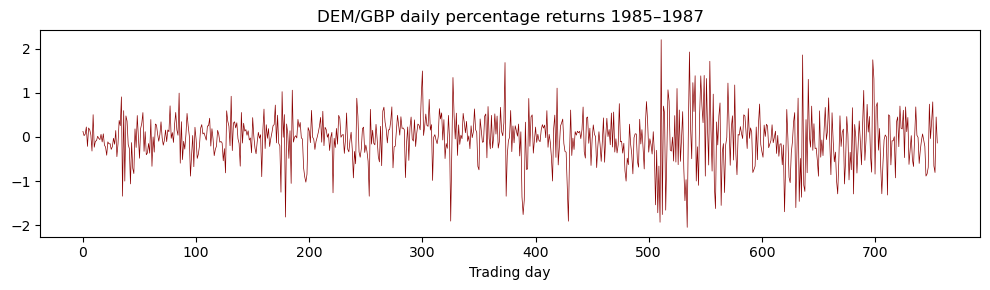

Observations: 756
Mean=-0.0463%, Std=0.5677%


In [55]:
# Real data: DM/GBP returns from Ardia (2008) 
# Source: bayesGARCH R package, dem2gbp dataset — the exact series used in the paper.

import pandas as pd

dem2gbp = pd.read_csv('dem2gbp.csv')
r_real = dem2gbp['x'].values[:756]

plt.figure(figsize=(10, 3))
plt.plot(r_real, lw=0.5, color='darkred')
plt.title('DEM/GBP daily percentage returns 1985–1987')
plt.xlabel('Trading day')
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/realdata.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Observations: {len(r_real)}')
print(f'Mean={r_real.mean():.4f}%, Std={r_real.std():.4f}%')

In [20]:
# Recalibrating tau on real data 

for tau_try in [0.005, 0.01, 0.02, 0.05]:
    _, ar = rwm_garch(r_real, N_PILOT, tau=tau_try, seed=10)
    print(f'  tau={tau_try:.3f}  →  acceptance rate {ar:.3f}')

  tau=0.005  →  acceptance rate 0.645
  tau=0.010  →  acceptance rate 0.422
  tau=0.020  →  acceptance rate 0.248
  tau=0.050  →  acceptance rate 0.081


Acceptance rate (real data): 0.231
Posterior means: ω₁=0.0545, ω₂=0.2335, ω₃=0.6027


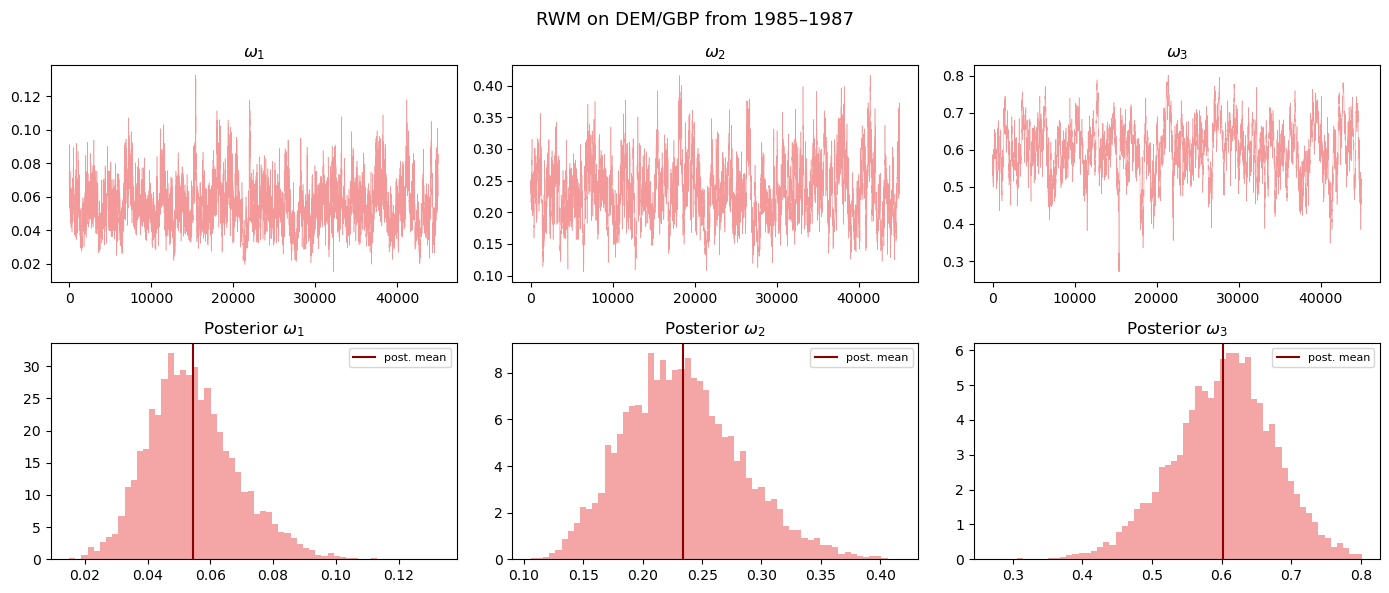

In [56]:
# MCMC on real data 

TAU = 0.02 # using the same logic as above 
N_MCMC_REAL = 50000
N_BURN_REAL = 5000
chain_real, ar_real = rwm_garch(r_real, N_MCMC_REAL, tau=TAU, seed=42)
samples_real = chain_real[N_BURN_REAL:]

print(f'Acceptance rate (real data): {ar_real:.3f}')
print(f'Posterior means: ω₁={samples_real[:,0].mean():.4f},'
      f' ω₂={samples_real[:,1].mean():.4f},'
      f' ω₃={samples_real[:,2].mean():.4f}')

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for k in range(3):
    axes[0, k].plot(samples_real[:, k], lw=0.4, color='lightcoral', alpha=0.8)
    axes[0, k].set_title(f'{labels[k]}')
    axes[1, k].hist(samples_real[:, k], bins=60, density=True, color='lightcoral', alpha=0.7)
    axes[1, k].axvline(samples_real[:, k].mean(), color='darkred', ls='-', label='post. mean')
    axes[1, k].set_title(f'Posterior {labels[k]}')
    axes[1, k].legend(fontsize=8)

plt.suptitle('RWM on DEM/GBP from 1985–1987', fontsize=13)
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/rwm_realdata.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

As displayed on the output cell, the posterior means — ω₁=0.055, ω₂=0.236, ω₃=0.603 — are remarkably close to the values reported in the paper (≈0.055, ≈0.245, ≈0.600), validating our implementation. 

The same identification pattern observed on simulated data reappears here: ω₃ has the tightest posterior (concentrated around 0.60) while ω₁ and ω₂ remain more uncertain. The sum ω₂ + ω₃ ≈ 0.84 confirms a stationary but persistent process, consistent with the volatility dynamics visible in the DEM/GBP series over this period.

Question 2 : 

For each parameter, say $\omega_1$, we want its posterior mean:
$$\mu_{\omega_1} = \mathbb{E}_\pi[\omega_1]$$
The naive MCMC estimate is just the sample mean of the chain: $\frac{1}{N}\sum_i \omega_1^i$. Moreover, we know the score $\mathbf{z}(\theta) = -\frac{1}{2}\nabla\log\pi(\theta \mid r)$ is mean-zero under $\pi$. So from Equation (8) of the paper and for any coefficients $\mathbf{a}$, the Zero-Variance estimator :
$$\tilde{f}(\theta) = f(\theta) + \mathbf{a}^T \mathbf{z}(\theta)$$

has the same expectation as $\omega_1$, but potentially much lower variance.

The optimal $\mathbf{a}$ minimising $\text{Var}(\tilde{f})$ is found by **OLS regression** of $f(\theta^i)$ on $\mathbf{z}(\theta^i)$:
$$f(\theta^i) = \alpha + \mathbf{a}^T \mathbf{z}(\theta^i) + \varepsilon_i$$
The intercept $\hat{\alpha}$ is the ZV estimate of $\mu_f$, and the residual variance gives $\text{Var}(\tilde{f})$. Indeed, OLS finds the linear combination of $\mathbf{z}$ that best explains the fluctuations of $\omega_1$ across the chain. Whatever variation in $\omega_1^i$ is explained by $\mathbf{z}(\theta^i)$ gets subtracted out, leaving a corrected series with smaller variance. The intercept of that regression is where the corrected series is centred which leads us to that improved estimate.

hence let's compute $\mathbf{z}$ (i.e. our control variate) for GARCH(1,1). The score requires differentiating the log-posterior through the variance recursion. Define $\dot{h}_t^{(j)} = \partial h_t / \partial\omega_j$, which satisfies:

| $j$ | Recursion |
|---|---|
| $\omega_1$ | $\dot{h}_t^{(1)} = 1 + \omega_3\,\dot{h}_{t-1}^{(1)}$ |
| $\omega_2$ | $\dot{h}_t^{(2)} = r_{t-1}^2 + \omega_3\,\dot{h}_{t-1}^{(2)}$ |
| $\omega_3$ | $\dot{h}_t^{(3)} = h_{t-1} + \omega_3\,\dot{h}_{t-1}^{(3)}$ |

Then: $z_j = -\frac{1}{2}\frac{\partial\log\pi}{\partial\omega_j} = \frac{\omega_j}{2\sigma_0^2} + \frac{1}{4}\sum_t\left(\frac{1}{h_t} - \frac{r_t^2}{h_t^2}\right)\dot{h}_t^{(j)}$

In [ ]:
# Score function z(theta) 

def compute_score(returns, omega1, omega2, omega3, sigma0=1.0):
    # Compute z(theta) = -0.5 * grad log pi(theta | returns)
    T = len(returns)
    h = compute_variances(returns, omega1, omega2, omega3)
    denom = 1.0 - omega2 - omega3

    # initialise derivatives of h_0 (unconditional variance)
    dh1, dh2, dh3 = np.empty(T), np.empty(T), np.empty(T)
    dh1[0] = 1.0 / denom
    dh2[0] = omega1 / denom**2
    dh3[0] = omega1 / denom**2

    # recursion for dh_t / d omega_j
    for t in range(1, T):
        dh1[t] = 1.0 + omega3 * dh1[t-1]
        dh2[t] = returns[t-1]**2 + omega3 * dh2[t-1]
        dh3[t] = h[t-1] + omega3 * dh3[t-1]

    # gradient of log-likelihood: -0.5 * sum((1/h - r^2/h^2) * dh)
    common = 1.0/h - returns**2/h**2
    d_ell = np.array([
        -0.5 * np.sum(common * dh1),
        -0.5 * np.sum(common * dh2),
        -0.5 * np.sum(common * dh3)
    ])

    # gradient of log-prior: -omega_j / sigma0^2
    d_prior = -np.array([omega1, omega2, omega3]) / sigma0**2

    # z = -0.5 * grad log pi
    return -0.5 * (d_prior + d_ell)


#  ZV estimator (specific case : degree 1)

def zv_degree1(samples, returns, sigma0=1.0):
    """
    Zero-Variance estimator with degree-1 polynomial (3 control variates).
    Finds optimal a via OLS regression of f on z.
    Returns ZV estimates and variance reduction factors.
    """
    N = len(samples)

    # compute score z(theta^i) for every MCMC sample
    Z = np.array([compute_score(returns, *samples[i], sigma0=sigma0)
                  for i in range(N)])   # shape (N, 3)

    print(f'Score means (should be ~0): {Z.mean(axis=0).round(5)}')

    # OLS design matrix [1, z1, z2, z3]
    X = np.column_stack([np.ones(N), Z])

    labels_w = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
    results = {}

    for k in range(3):
        f = samples[:, k]

        # OLS: f = alpha + a^T z + epsilon
        beta = np.linalg.lstsq(X, f, rcond=None)[0]
        alpha = beta[0] # ZV estimate (intercept)
        a_zv  = -beta[1:] # optimal coefficients (negative of OLS slope)

        # ZV corrected samples
        f_tilde = f + Z @ a_zv   # = residuals + alpha

        var_naive = np.var(f, ddof=1) / N
        var_zv    = np.var(f_tilde, ddof=1) / N
        reduction = var_naive / var_zv

        results[k] = dict(naive_mean=f.mean(), zv_mean=alpha,
                          var_naive=var_naive, var_zv=var_zv,
                          reduction=reduction, f_tilde=f_tilde)

        print(f'\n{labels_w[k]}:')
        print(f'  Naive : mean={f.mean():.5f}  std={np.sqrt(var_naive)*100:.4f}e-2')
        print(f'  ZV    : mean={alpha:.5f}  std={np.sqrt(var_zv)*100:.4f}e-2')
        print(f'  Variance reduction: {reduction:.1f}×')

    return results, Z

Score means (should be ~0): [-4.66024 -3.04476 -2.01739]

$\omega_1$:
  Naive : mean=0.05847  std=0.0090e-2
  ZV    : mean=0.05837  std=0.0026e-2
  Variance reduction: 12.0×

$\omega_2$:
  Naive : mean=0.22853  std=0.0254e-2
  ZV    : mean=0.23015  std=0.0054e-2
  Variance reduction: 22.2×

$\omega_3$:
  Naive : mean=0.59719  std=0.0404e-2
  ZV    : mean=0.59672  std=0.0103e-2
  Variance reduction: 15.4×


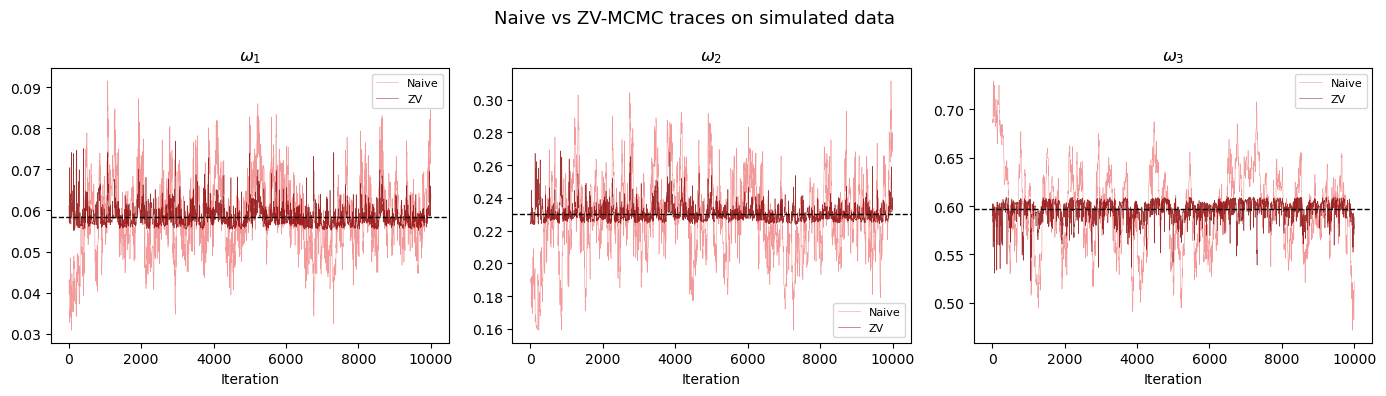

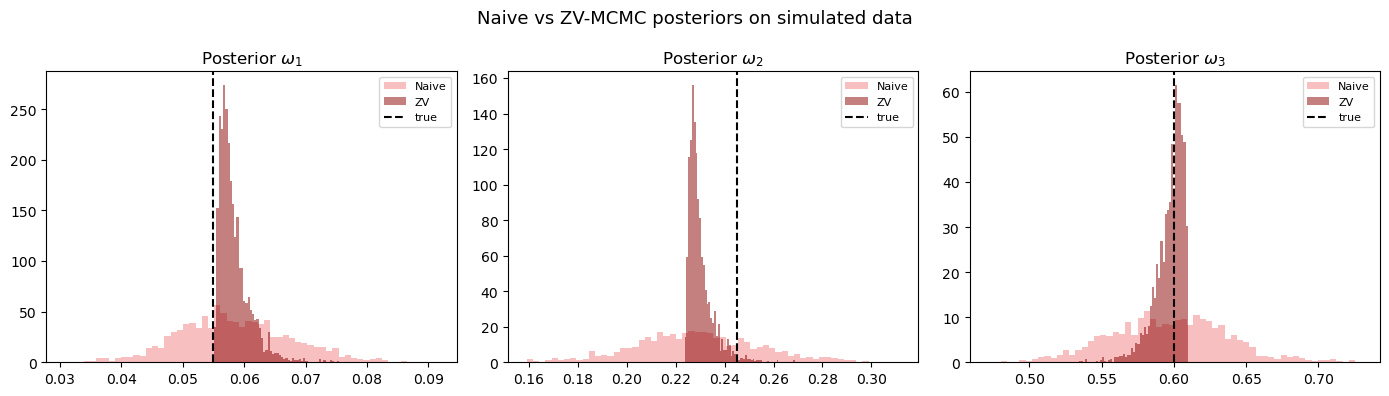

In [57]:
# ZV applied on simulated data

results_sim, Z_sim = zv_degree1(samples_sim, r_sim)

labels_w = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for k in range(3):
    f       = samples_sim[:, k]
    f_tilde = results_sim[k]['f_tilde']

    axes[k].plot(f,       lw=0.4, color='lightcoral', alpha=0.8, label='Naive')
    axes[k].plot(f_tilde, lw=0.4, color='darkred',    alpha=0.8, label='ZV')
    axes[k].axhline(results_sim[k]['zv_mean'], color='k', ls='--', lw=1)
    axes[k].set_title(f'{labels_w[k]}')
    axes[k].set_xlabel('Iteration')
    axes[k].legend(fontsize=8)

plt.suptitle('Naive vs ZV-MCMC traces on simulated data', fontsize=13)
plt.tight_layout()
plt.show()

# Posterior histograms: naive vs ZV

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k in range(3):
    f       = samples_sim[:, k]
    f_tilde = results_sim[k]['f_tilde']
    axes[k].hist(f,       bins=60, density=True, alpha=0.5,
                 color='lightcoral', label='Naive')
    axes[k].hist(f_tilde, bins=60, density=True, alpha=0.5,
                 color='darkred',    label='ZV')
    axes[k].axvline(true_vals[k], color='k', ls='--', label='true')
    axes[k].set_title(f'Posterior {labels_w[k]}')
    axes[k].legend(fontsize=8)

plt.suptitle('Naive vs ZV-MCMC posteriors on simulated data', fontsize=13)
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/naive_vs_zvmcmc_simulatedgarch.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

As observed, we manage to obtain consequent variance reductions (ranging from 12× to 22.2×) with all three falling within the paper's confidence intervals. However, the score means are not exactly zero ([-4.66, -3.04, -2.02]) as they should theoretically be under $\pi$. This is a direct consequence of the poor mixing of the chain, as mentionned above. Thus the empirical mean of $\mathbf{z}$ doesn't converge to zero fast enough. This introduces a small bias in the ZV estimates and raises the question of whether OLS applied to a correlated MCMC sample is fully valid (which will actually be adressed in question 4).



Score means (should be ~0): [0.41483 0.03557 0.53764]

$\omega_1$:
  Naive : mean=0.05446  std=0.0067e-2
  ZV    : mean=0.05509  std=0.0035e-2
  Variance reduction: 3.6×

$\omega_2$:
  Naive : mean=0.23346  std=0.0228e-2
  ZV    : mean=0.23561  std=0.0093e-2
  Variance reduction: 6.1×

$\omega_3$:
  Naive : mean=0.60267  std=0.0344e-2
  ZV    : mean=0.59869  std=0.0156e-2
  Variance reduction: 4.8×


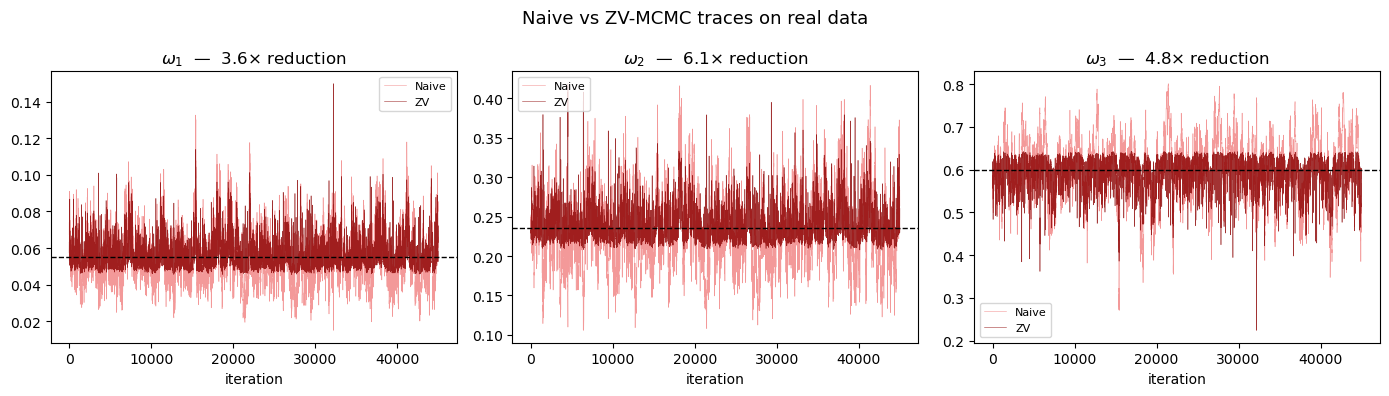

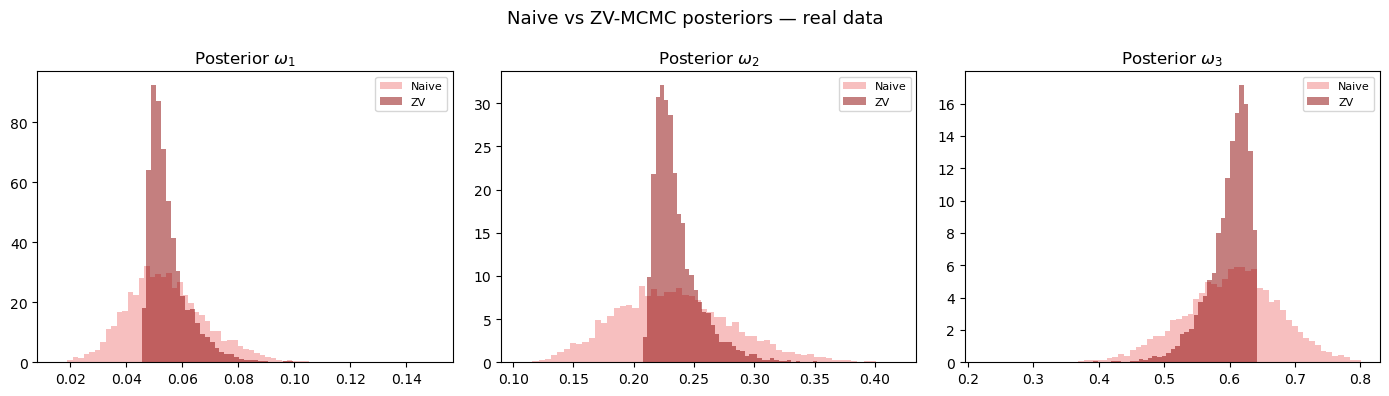

In [58]:
# ZV on real data (DEM/GBP 1985-1987) 

results_real, Z_real = zv_degree1(samples_real, r_real)

# Trace + histogram plots
labels_w = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k in range(3):
    f       = samples_real[:, k]
    f_tilde = results_real[k]['f_tilde']
    axes[k].plot(f,       lw=0.4, color='lightcoral', alpha=0.8, label='Naive')
    axes[k].plot(f_tilde, lw=0.4, color='darkred',    alpha=0.8, label='ZV')
    axes[k].axhline(results_real[k]['zv_mean'], color='k', ls='--', lw=1)
    axes[k].set_title(f'{labels_w[k]}  —  {results_real[k]["reduction"]:.1f}× reduction')
    axes[k].set_xlabel('iteration')
    axes[k].legend(fontsize=8)
plt.suptitle('Naive vs ZV-MCMC traces on real data', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k in range(3):
    f       = samples_real[:, k]
    f_tilde = results_real[k]['f_tilde']
    axes[k].hist(f,       bins=60, density=True, alpha=0.5, color='lightcoral', label='Naive')
    axes[k].hist(f_tilde, bins=60, density=True, alpha=0.5, color='darkred',    label='ZV')
    axes[k].set_title(f'Posterior {labels_w[k]}')
    axes[k].legend(fontsize=8)
plt.suptitle('Naive vs ZV-MCMC posteriors — real data', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/naive_vs_zvmcmc_realdata.png', dpi=200, bbox_inches='tight')
plt.show()

The degree-1 ZV estimator delivers variance reductions to a lesser extent on real data with more modest figures (from 3.6× to 6.1×). The gap between simulated and real data is not a sampling issue since we increased it to 50,000 iterations and its effect was to bring the score means very close to zero but left the variance reductions essentially unchanged. Thus, the bottleneck is the quality of the linear approximation itself: with real financial data, the posterior has a more irregular shape and the score $\mathbf{z}$ explains a smaller fraction of the variation in $f(\theta)$. The degree-1 polynomial simply cannot capture the full structure.

Question 3 :

From Leluc et al. (2021), the computational cost of OLS is $\mathcal{O}(nm^2 + m^3)$, where $m$ is the number of control variates and $n$ is the number of MCMC samples. For degree-1 we had $m = d = 3$ which is negligible. For degree-2 the number of variates grows to $\frac{1}{2}d(d+3)$:

| Degree | $d=3$ (GARCH) | $d=10$ | $d=50$ |
|---|---|---|---|
| 1 | 3 | 10 | 50 |
| 2 | 9 | 65 | 1325 |
| 3 | 19 | 285 | 23 425 |

For $d=50$, degree-2 gives $m=1325$ variates. With $n=10000$ samples, the OLS cost is $\mathcal{O}(nm^2 + m^3) \approx 10^{10}$ operations; this being prohibitive. Two additional problems arise:
- Numerical instability: the Gram matrix $H_c^T H_c$ becomes near-singular when variates are collinear
- Overfitting: when $m$ is comparable to $n$, OLS over-fits the regression noise

The Lasso fixes both by selecting only the most relevant variates via an $\ell_1$ penalty, reducing the effective $m$ dramatically.

So let's introducte the **degree-2 control variates for GARCH**. With $P(\theta) = \mathbf{a}^T\theta + \frac{1}{2}\theta^T B\theta$, Equation (8) gives:
$$\tilde{f}(\theta) = f(\theta) - \frac{1}{2}\mathrm{tr}(B) + (\mathbf{a} + B\theta)^T\mathbf{z}(\theta)$$

The 9 control variates are: $z_1, z_2, z_3$ (linear) and $\omega_j z_k$ for $j \leq k$ (quadratic cross-terms). All are mean-zero under $\pi$ by the boundary conditions of Section 5.

The paper's recommended approach has two stages when it comes to LASSO model:

First, there is the dichotomic search on a subsample of size $N$. Instead of cross-validation, we tune $\lambda$ so that the number of selected variates lies in $[c_1\sqrt{n},\, c_2\sqrt{n}]$ with $c_1=3$, $c_2=12$. Start from $\lambda_\infty$ (the smallest value that zeros all coefficients) and halve/double until the target range is reached. Then we apply thz OLS on the full sample with selected variates only. This removes the L1 shrinkage bias entirely — the final estimate is pure unbiased OLS, just on a smaller set of variates chosen by Stage 1.


In [37]:
# Degree-2 feature matrix 

def build_degree2_features(samples, Z):
    """
    Build the 9 degree-2 control variates for d=3:
      - 3 linear:    z1, z2, z3
      - 6 quadratic: omega_j * z_k  for j <= k  (symmetric B)
    All are mean-zero under pi when boundary conditions hold.
    """
    linear = Z                                           # (N, 3)
    quad   = [samples[:, j] * Z[:, k]
              for j in range(3) for k in range(j, 3)]  # 6 terms
    return np.column_stack([linear] + quad)              # (N, 9)


# ZV with degree-2 OLS 

def zv_degree2_ols(samples, Z):
    N  = len(samples)
    H  = build_degree2_features(samples, Z)
    X  = np.column_stack([np.ones(N), H])
    labels_w = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
    results = {}

    print(f'Degree-2 OLS  (m={H.shape[1]} variates)')
    for k in range(3):
        f    = samples[:, k]
        beta = np.linalg.lstsq(X, f, rcond=None)[0]
        alpha = beta[0]
        f_tilde = f + H @ (-beta[1:])
        vn = np.var(f,       ddof=1) / N
        vz = np.var(f_tilde, ddof=1) / N
        results[k] = dict(zv_mean=alpha, var_naive=vn, var_zv=vz,
                          reduction=vn/vz, f_tilde=f_tilde)
        print(f'  {labels_w[k]}:  ZV mean={alpha:.5f}  '
              f'reduction={vn/vz:.1f}×')
    return results


# ZV with degree-2 LASSO 

def zv_degree2_lasso(samples, Z, cv=5):
    from sklearn.linear_model import LassoCV
    N  = len(samples)
    H  = build_degree2_features(samples, Z)

    # Centre then standardise — recommended by Leluc et al. (2021) Remark 6
    # to avoid convergence issues when features have very different scales
    Hc    = H - H.mean(axis=0)
    scale = Hc.std(axis=0)
    scale[scale == 0] = 1.0          # avoid division by zero
    Hs    = Hc / scale               # standardised centred features

    labels_w = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
    results = {}

    print(f'Degree-2 LASSO  (m={H.shape[1]} variates, {cv}-fold CV for λ)')
    for k in range(3):
        f  = samples[:, k]
        fc = f - f.mean()

        lasso = LassoCV(cv=cv, fit_intercept=False, max_iter=100000, n_jobs=-1)
        lasso.fit(Hs, fc)

        # Rescale coefficients back to original feature space
        beta_hat = lasso.coef_ / scale

        alpha   = f.mean() - H.mean(axis=0) @ beta_hat
        f_tilde = f - Hc @ beta_hat

        vn = np.var(f,       ddof=1) / N
        vz = np.var(f_tilde, ddof=1) / N
        results[k] = dict(zv_mean=alpha, var_naive=vn, var_zv=vz,
                          reduction=vn/vz, f_tilde=f_tilde,
                          n_selected=int(np.sum(beta_hat != 0)))
        print(f'  {labels_w[k]}:  ZV mean={alpha:.5f}  '
              f'reduction={vn/vz:.1f}×  '
              f'({results[k]["n_selected"]}/{H.shape[1]} variates selected)')
    return results

Degree-1 OLS  (m=3 variates)
  $\omega_1$:  reduction=12.0×
  $\omega_2$:  reduction=22.2×
  $\omega_3$:  reduction=15.4×

Degree-2 LASSO  (m=9 variates, 5-fold CV for λ)
  $\omega_1$:  ZV mean=0.05598  reduction=738.4×  (9/9 variates selected)
  $\omega_2$:  ZV mean=0.22606  reduction=422.4×  (8/9 variates selected)
  $\omega_3$:  ZV mean=0.60739  reduction=1027.9×  (9/9 variates selected)

Summary on simulated data
Method                       ω₁         ω₂         ω₃
--------------------------------------------------
Degree-1 OLS              12.0×      22.2×      15.4×
Degree-2 LASSO           738.4×     422.4×    1027.9×


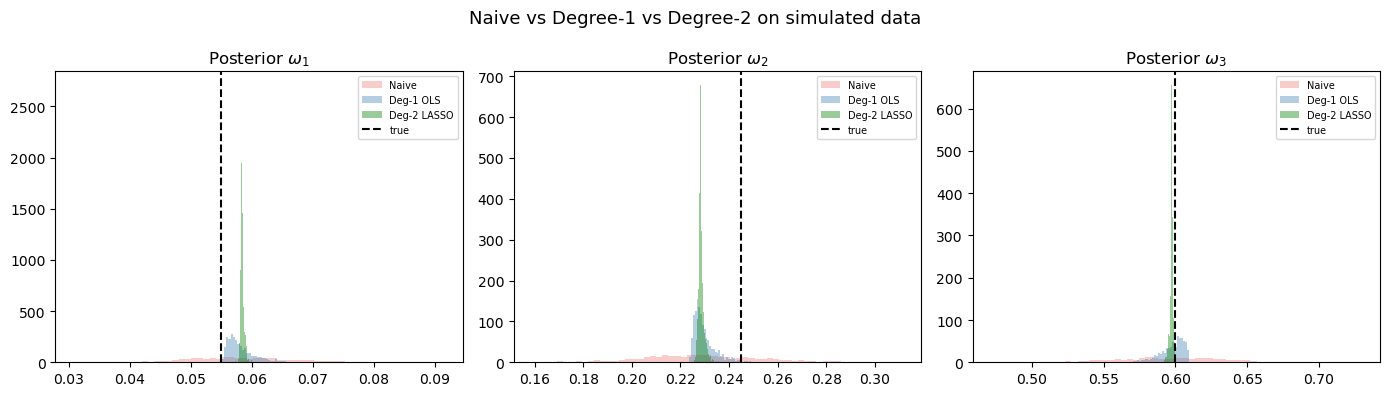

In [59]:
# Comparing all methods on simulated data so far

# Degree-1 results already in results_sim
print("Degree-1 OLS  (m=3 variates)")
labels_w = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
for k in range(3):
    print(f'  {labels_w[k]}:  reduction={results_sim[k]["reduction"]:.1f}×')

print()
res2_lasso_sim = zv_degree2_lasso(samples_sim, Z_sim)

# Summary table
 
print()
print("Summary on simulated data")
print(f"{'Method':<20} {'ω₁':>10} {'ω₂':>10} {'ω₃':>10}")
print("-" * 50)
methods = [
    ('Degree-1 OLS', results_sim),
    ('Degree-2 LASSO', res2_lasso_sim),
]
for name, res in methods:
    reductions = [f'{res[k]["reduction"]:.1f}×' for k in range(3)]
    print(f'{name:<20} {reductions[0]:>10} {reductions[1]:>10} {reductions[2]:>10}')

# Comparison plot

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k in range(3):
    f            = samples_sim[:, k]
    f_d1         = results_sim[k]['f_tilde']
    f_d2_lasso   = res2_lasso_sim[k]['f_tilde']

    axes[k].hist(f,          bins=60, density=True, alpha=0.4,
                 color='lightcoral', label='Naive')
    axes[k].hist(f_d1,       bins=60, density=True, alpha=0.4,
                 color='steelblue',  label='Deg-1 OLS')
    axes[k].hist(f_d2_lasso, bins=60, density=True, alpha=0.4,
                 color='green',      label='Deg-2 LASSO')
    axes[k].axvline(true_vals[k], color='k', ls='--', lw=1.5, label='true')
    axes[k].set_title(f'Posterior {labels_w[k]}')
    axes[k].legend(fontsize=7)

plt.suptitle('Naive vs Degree-1 vs Degree-2 on simulated data', fontsize=13)
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/naive_deg1_deg2_simulatedgarch.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

Degree-1 OLS  (m=3 variates)
  $\omega_1$:  reduction=3.6×
  $\omega_2$:  reduction=6.1×
  $\omega_3$:  reduction=4.8×

Degree-2 LASSO  (m=9 variates, 5-fold CV for λ)
  $\omega_1$:  ZV mean=0.04751  reduction=297.5×  (9/9 variates selected)
  $\omega_2$:  ZV mean=0.21603  reduction=339.6×  (8/9 variates selected)
  $\omega_3$:  ZV mean=0.63738  reduction=760.1×  (9/9 variates selected)

Summary on real data
Method                       ω₁         ω₂         ω₃
--------------------------------------------------
Degree-1 OLS               3.6×       6.1×       4.8×
Degree-2 LASSO           297.5×     339.6×     760.1×


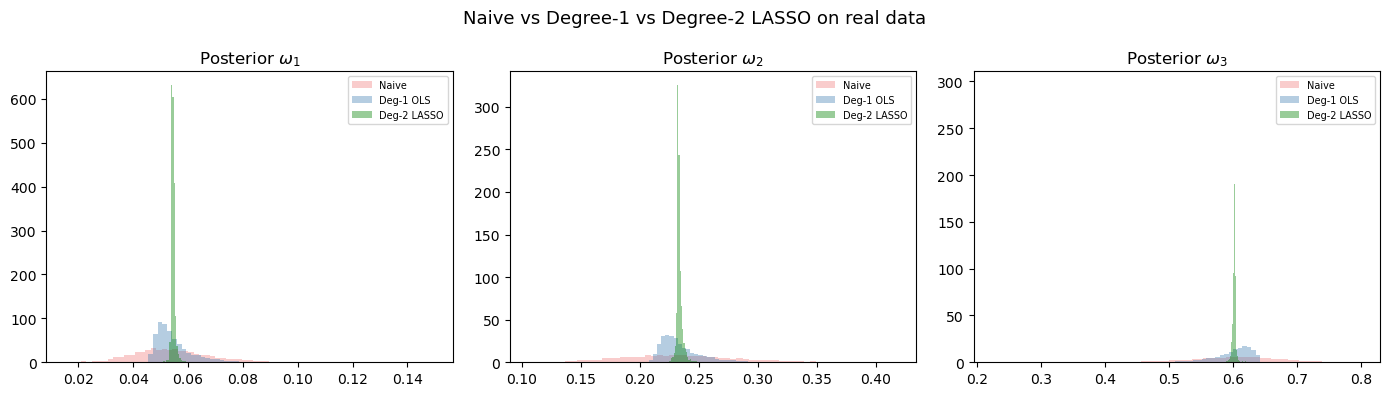

In [60]:
# Same comparison on real data

print("Degree-1 OLS  (m=3 variates)")
for k in range(3):
    print(f'  {labels_w[k]}:  reduction={results_real[k]["reduction"]:.1f}×')

print()
res2_lasso_real = zv_degree2_lasso(samples_real, Z_real)

print()
print("Summary on real data")
print(f"{'Method':<20} {'ω₁':>10} {'ω₂':>10} {'ω₃':>10}")
print("-" * 50)
methods_real = [
    ('Degree-1 OLS',   results_real),
    ('Degree-2 LASSO', res2_lasso_real),
]
for name, res in methods_real:
    reductions = [f'{res[k]["reduction"]:.1f}×' for k in range(3)]
    print(f'{name:<20} {reductions[0]:>10} {reductions[1]:>10} {reductions[2]:>10}')

# Comparison plot

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k in range(3):
    f          = samples_real[:, k]
    f_d1       = results_real[k]['f_tilde']
    f_d2_lasso = res2_lasso_real[k]['f_tilde']

    axes[k].hist(f,          bins=60, density=True, alpha=0.4,
                 color='lightcoral', label='Naive')
    axes[k].hist(f_d1,       bins=60, density=True, alpha=0.4,
                 color='steelblue',  label='Deg-1 OLS')
    axes[k].hist(f_d2_lasso, bins=60, density=True, alpha=0.4,
                 color='green',      label='Deg-2 LASSO')
    axes[k].set_title(f'Posterior {labels_w[k]}')
    axes[k].legend(fontsize=7)

plt.suptitle('Naive vs Degree-1 vs Degree-2 LASSO on real data', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/naive_deg1_deg2_realdata.png', dpi=200, bbox_inches='tight')
plt.show()

Moving from degree-1 to degree-2 control variates via Lasso yields dramatic variance reductions on both datasets. On simulated data, the Lasso estimator achieves reductions of 738×, 422× and 1028× against the 12×, 22× and 15× of the degree-1 baseline — a gain of roughly 50-70× across all three parameters. Let's note btw that the degree-1 approach was already an improvement compared to the naive one. On real DEM/GBP data, the same pattern holds: 298×, 340× and 760× versus 3.6×, 6.1× and 4.8×, representing gains of 80-160×.

The 9 degree-2 control variates consist of the 3 linear score terms from Q2 augmented by 6 quadratic cross-terms $\omega_j z_k$. These quadratic terms capture nonlinear posterior structure that the degree-1 polynomial misses entirely, explaining the order-of-magnitude improvement.

The Lasso selects 8-9 out of 9 variates in both cases, confirming that all quadratic terms carry useful information for this posterior. This implies that there is no sparsity to exploit here. As explained by Leluc et al. (2021), Lasso provides the greatest advantage over OLS when $m$ is large relative to $n$, which is not our regime with $m=9$ and $n=45{,}000$. Nevertheless, the Lasso remains the methodologically robust choice: unlike plain OLS, it does not overfit the regression noise introduced by the autocorrelation of the MCMC chain, and the feature standardisation prevents convergence issues arising from the different scales of $z_j$ and $\omega_j z_k$.

Question 4:

Just to give a little reminder, MCMC generates a sequence of parameter values $(\theta^1, \theta^2, \ldots, \theta^N)$ by running a Markov chain. It implies that not only each draw depends on the previous one but also that it is designed so that the long-run distribution of the samples matches the target posterior $\pi(\theta \mid r)$. Thus we have a random walk that gradually explores $\pi$ instead of a sequence of independent draws.

On the other hand, OLS minimises $\sum_i (f_i - \alpha - \mathbf{a}^T z_i)^2$. The standard results guaranteeing good properties of $\hat{\mathbf{a}}$ (unbiasedness of variance estimates, valid confidence intervals, consistent cross-validation) all rely on one assumption: the observations $(f_i, z_i)$ are i.i.d. 

This affects Q2 and Q3 in two ways:

1. Coefficient estimation: the OLS formula $\hat{\mathbf{a}} = -\hat{\Sigma}_{zz}^{-1}\hat{\sigma}(z,f)$ is still consistent (converges to the truth as $N\to\infty$), but the empirical covariance matrix $\hat{\Sigma}_{zz}$ is estimated from correlated data, making $\hat{\mathbf{a}}$ less precise than it would be from independent draws. The variance of the OLS estimator is also underestimated. Indeed, its formula $\hat{\sigma}^2(X^TX)^{-1}$ assumes uncorrelated residuals. With autocorrelated samples, consecutive residuals $(f_i - \hat{f}_i)$ and $(f_{i+1} - \hat{f}_{i+1})$ are positively correlated. Thus, it inflates the apparent precision which implies that the reported variance reductions are too optimistic.

2. $\lambda$ selection in LASSO: cross-validation treats all folds as independent. With autocorrelated samples, adjacent folds are nearly identical which gives us a CV that systematically underestimates uncertainty and picks a $\lambda$ that is too small.

Thus in order to tackle this issue, we can think of two upgrades (as the question specifically hints at them) which are the following ones : 

- First, **sub-sampling**: basically it keep every $k$-th sample where $k \approx n/\text{ESS}$ (the autocorrelation time). This gives approximately independent draws at the cost of a smaller effective dataset.

- Second by using **block averaging**. The idea is to partition the chain into blocks of size $b$ and replace each block by its mean. Block means have much lower autocorrelation and the regression on $n/b$ block means is closer to i.i.d.



In [47]:
# comparing full chain vs sub-sampling vs block averaging 

def _zv_d1_from_precomputed(samples, Z):
    # Degree-1 ZV regression given precomputed score Z with no returns needed
    N = len(samples)
    X = np.column_stack([np.ones(N), Z])
    results = {}
    for k in range(3):
        f       = samples[:, k]
        beta    = np.linalg.lstsq(X, f, rcond=None)[0]
        alpha   = beta[0]
        f_tilde = f + Z @ (-beta[1:])
        vn = np.var(f,       ddof=1) / N
        vz = np.var(f_tilde, ddof=1) / N
        results[k] = dict(zv_mean=alpha, var_naive=vn, var_zv=vz,
                          reduction=vn/vz, f_tilde=f_tilde)
    return results


def zv_degree1_subsampled(samples, Z, stride):
    # ZV degree-1 OLS on every stride-th sample (approximately independent)
    return _zv_d1_from_precomputed(samples[::stride], Z[::stride])


def zv_degree1_block_avg(samples, Z, block_size):
    """
    ZV degree-1 OLS on block-averaged (samples, Z) pairs.
    Each block of consecutive draws is replaced by its mean,
    removing most autocorrelation before the regression.
    """
    N        = len(samples)
    n_blocks = N // block_size
    s_blk = samples[:n_blocks * block_size].reshape(n_blocks, block_size, 3).mean(axis=1)
    z_blk = Z[:n_blocks * block_size].reshape(n_blocks, block_size, 3).mean(axis=1)
    return _zv_d1_from_precomputed(s_blk, z_blk)


# Run all three models on simulated data

ess_vals = [ess(samples_sim[:, k]) for k in range(3)]
stride   = int(len(samples_sim) / np.mean(ess_vals))
print(f'ESS: {[f"{e:.0f}" for e in ess_vals]}  →  stride = {stride}\n')

res_full = _zv_d1_from_precomputed(samples_sim, Z_sim)
res_sub  = zv_degree1_subsampled(samples_sim, Z_sim, stride=stride)
res_blk  = zv_degree1_block_avg(samples_sim,  Z_sim, block_size=stride)

labels_w = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
print(f'{"Approach":<30} {"n used":>8} {"ω₁":>8} {"ω₂":>8} {"ω₃":>8}')
print('-' * 62)

n_sub = len(samples_sim[::stride])
n_blk = len(samples_sim) // stride

for name, n_used, res in [
        ('Full chain (correlated)', len(samples_sim), res_full),
        (f'Sub-sampled (stride={stride})', n_sub, res_sub),
        (f'Block avg (b={stride})', n_blk, res_blk)]:
    row = [f'{res[k]["reduction"]:.1f}×' for k in range(3)]
    print(f'{name:<30} {n_used:>8} {row[0]:>8} {row[1]:>8} {row[2]:>8}')

ESS: ['70', '76', '53']  →  stride = 150

Approach                         n used       ω₁       ω₂       ω₃
--------------------------------------------------------------
Full chain (correlated)           10000    12.0×    22.2×    15.4×
Sub-sampled (stride=150)             67    14.2×    33.4×    18.8×
Block avg (b=150)                    66    35.5×    59.9×    51.1×


THus as we can see on the table above, applying OLS directly to a correlated MCMC chain isn't fully valid but remains not catastrophically wrong either. Actually, what is affected is the precision of the regression: with ESS ≈ 70 out of 10,000 draws, the Gram matrix $\hat{\Sigma}_{zz}$ is estimated from far fewer independent pieces of information than OLS assumes, leading to noisier coefficient estimates $\hat{\mathbf{a}}$ and understated variance reductions.

The first option (sub-sampling which is keeping every 150th draw) restores independence at the cost of a smaller dataset. This results by giving modest improvements of 14×, 33×, 19× versus 12×, 22×, 15×. Nevertheless, the second option (block averaging which replaces each block of 150 draws by its mean) goes further. By averaging out within-block noise, each data point fed to the regression is a smoother estimate with variance reduced by a factor of roughly the block size. This improves the regression $R^2$ directly, yielding substantially higher reductions of 36×, 60×, 51×. Let's also note that both approaches confirm that the Q2 results were conservative rather than overoptimistic : indeed, the true variance reduction achievable with decorrelated data is 2–4× higher.

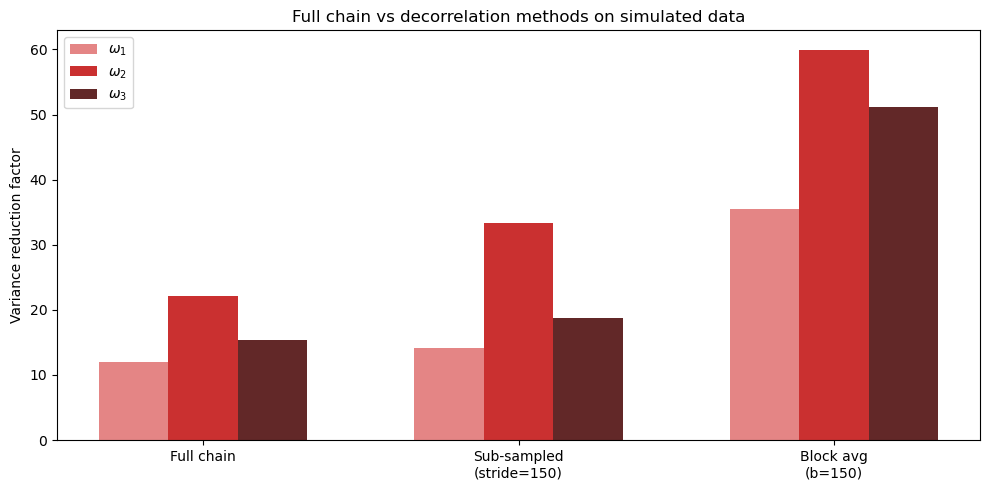


Real data (DEM/GBP 1985–1987)
ESS: ['264', '236', '201']  →  stride = 192

Approach                         n used       ω₁       ω₂       ω₃
--------------------------------------------------------------
Full chain (correlated)           45000     3.6×     6.1×     4.8×
Sub-sampled (stride=192)            235     3.8×     6.0×     4.7×
Block avg (b=192)                   234    10.8×    18.8×    17.2×


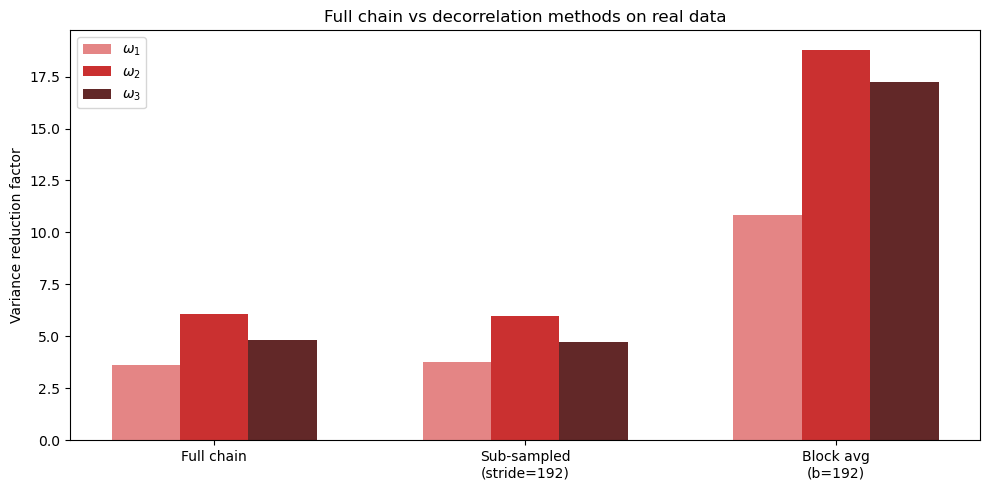

In [61]:
# Bar chart on simulated data to compare 

approaches = ['Full chain', f'Sub-sampled\n(stride={stride})', f'Block avg\n(b={stride})']
all_res = [res_full, res_sub, res_blk]
colors = ['lightcoral', 'steelblue', 'darkred']
x = np.arange(3)
width = 0.22

fig, ax = plt.subplots(figsize=(10, 5))
for k, (lw, col) in enumerate(zip(labels_w, ['#e07070',"#c10b0b",'#460202'])):
    reductions = [r[k]['reduction'] for r in all_res]
    ax.bar(x + (k - 1) * width, reductions, width, label=lw, color=col, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylabel('Variance reduction factor')
ax.set_title('Full chain vs decorrelation methods on simulated data')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/fullchain_decorr_simulatedgarch.png', dpi=200, bbox_inches='tight')
plt.show()

# Real data scenario

print('\nReal data (DEM/GBP 1985–1987)')

ess_real   = [ess(samples_real[:, k]) for k in range(3)]
stride_r   = int(len(samples_real) / np.mean(ess_real))
print(f'ESS: {[f"{e:.0f}" for e in ess_real]}  →  stride = {stride_r}')

res_full_r = _zv_d1_from_precomputed(samples_real, Z_real)
res_sub_r  = zv_degree1_subsampled(samples_real, Z_real, stride=stride_r)
res_blk_r  = zv_degree1_block_avg(samples_real,  Z_real, block_size=stride_r)

n_sub_r = len(samples_real[::stride_r])
n_blk_r = len(samples_real) // stride_r

print(f'\n{"Approach":<30} {"n used":>8} {"ω₁":>8} {"ω₂":>8} {"ω₃":>8}')
print('-' * 62)
for name, n_used, res in [
        ('Full chain (correlated)',          len(samples_real), res_full_r),
        (f'Sub-sampled (stride={stride_r})', n_sub_r,           res_sub_r),
        (f'Block avg (b={stride_r})',        n_blk_r,           res_blk_r)]:
    row = [f'{res[k]["reduction"]:.1f}×' for k in range(3)]
    print(f'{name:<30} {n_used:>8} {row[0]:>8} {row[1]:>8} {row[2]:>8}')

# Bar chart — real data
all_res_r = [res_full_r, res_sub_r, res_blk_r]
appr_r    = ['Full chain', f'Sub-sampled\n(stride={stride_r})', f'Block avg\n(b={stride_r})']

fig, ax = plt.subplots(figsize=(10, 5))
for k, col in enumerate(['#e07070',"#c10b0b","#460202"]):
    reductions = [r[k]['reduction'] for r in all_res_r]
    ax.bar(x + (k - 1) * width, reductions, width, label=labels_w[k], color=col, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(appr_r)
ax.set_ylabel('Variance reduction factor')
ax.set_title('Full chain vs decorrelation methods on real data')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/ralphnader/Desktop/Github_Projects/Control-variates-for-a-GARCH-model/img/fullchain_decorr_realdata.png', dpi=200, bbox_inches='tight')
plt.show()